In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


1. Veri seti yükleniyor ve normalizasyon yapılıyor...

--- 2. Modellerin Eğitimi Başlıyor ---
>> Standart SGD modeli eğitiliyor...


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


>> SGD + Momentum modeli eğitiliyor...
>> RMSprop modeli eğitiliyor...
>> Adam modeli eğitiliyor...

--- 3. Eğitim Bitti! Grafikler Çiziliyor ---


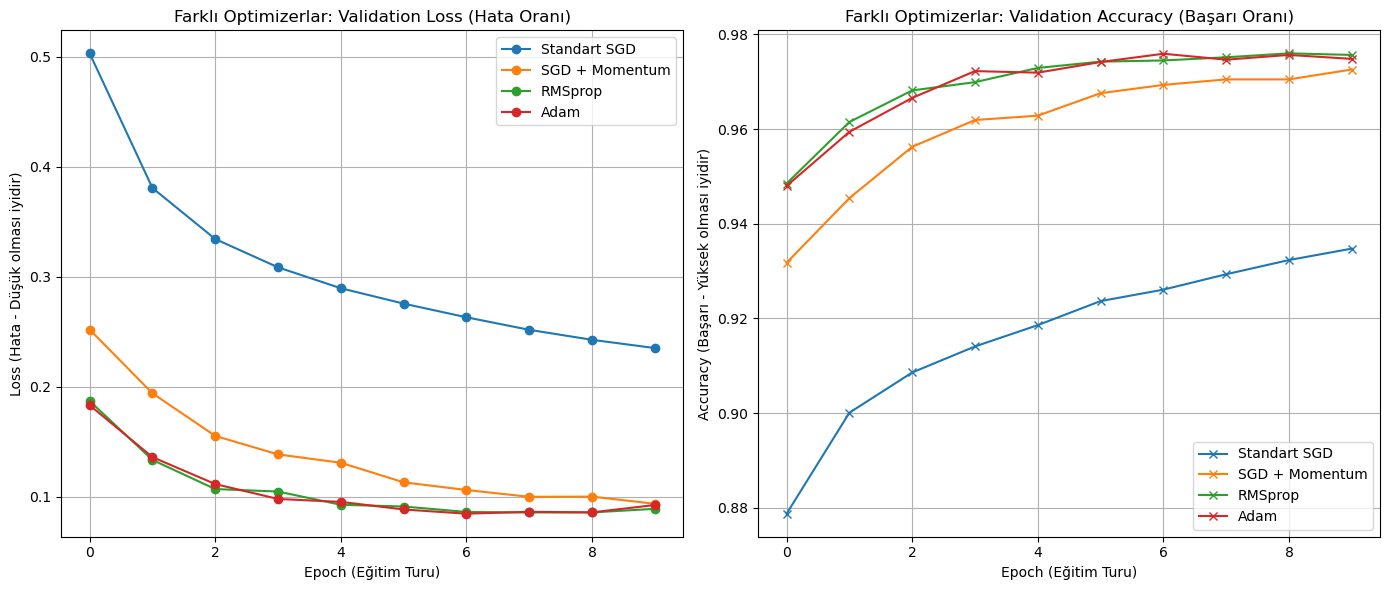

In [2]:
# %matplotlib inline: Jupyter Notebook'un grafikleri ayrı bir pencerede değil, 
# doğrudan bu hücrenin altında çizmesini sağlayan komuttur.
#tensorflow: yz/derin öğrenme kütüphanesi
#matplotlib: grafik çizim kütüphanesi
%matplotlib inline

import tensorflow as tf
import matplotlib.pyplot as plt

# =====================================================================
# 1. VERİ YÜKLEME VE NORMALİZASYON (Sunum Madde 1: Input Scaling)
# =====================================================================
print("1. Veri seti yükleniyor ve normalizasyon yapılıyor...")

# MNIST veri setini indiriyoruz.
#train ile eğitiliyor, test ile test ediliyor
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Görüntü pikselleri normalde 0 ile 255 arasındadır.
# Modelin daha hızlı öğrenmesi ve "Gradient" problemlerini (exploding/vanishing gradyanlar)
# önlemek için tüm pikselleri 255'e bölerek 0 ile 1 arasına sıkıştırıyoruz (Scaling).
x_train, x_test = x_train / 255.0, x_test / 255.0 


# =====================================================================
# 2. MODEL MİMARİSİ OLUŞTURMA (Sunum Madde 3: Weight Initialization)
# =====================================================================
def build_model():
    #sequential: Sıralı dizim
    model = tf.keras.models.Sequential([
        # 28x28 piksellik görüntüyü tek boyutlu (784 elemanlı) bir düz çizgiye çevirir.
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        
        # 128 nöronlu gizli katman. 'relu' aktivasyon fonksiyonu kullanıyoruz.
        # Not: Keras varsayılan olarak "Glorot (Xavier) Uniform" Weight Initialization kullanır.
        #relu: negatif sayıları 0 yapan, pozitif sayılara dokunmayan aktivasyon fonk.
        tf.keras.layers.Dense(128, activation='relu'), 
        
        # 10 farklı rakam (0-9) olduğu için çıkış katmanında 10 nöron var.
        #softmax fonksiyonu: çıkışları olasılık yüzdelerine (toplamı 1 olacak şekilde) çevirir.
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model


# =====================================================================
# 3. OPTİMİZER (İYİLEŞTİRİCİ) LİSTESİ (Sunum Madde 6: Gelişmiş Algoritmalar)
# =====================================================================
optimizers = {
    # Klasik Yöntem: Sadece anlık eğime (gradyan) bakar. Yavaştır. Bu yüzden lr'i yüksek tuttuk.
    'Standart SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    
    # Momentum: SGD'ye fiziksel bir ivme katar. Önceki adımların hızını hatırlar, 
    # böylece takılmadan daha hızlı ilerler.
    'SGD + Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    
    # RMSprop: Her ağırlık için öğrenme oranını (learning rate) otomatik ayarlar.
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    
    # Adam: Hem Momentum'un ivmesini hem de RMSprop'un otomatik hız ayarını birleştirir.
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}


# =====================================================================
# 4. EĞİTİM (TRAINING) AŞAMASI (Sunum Madde 4 & 5: Mini-batch)
# =====================================================================
history_dict = {}
epochs = 10 # Model veriyi 10 kez baştan sona görecek.

# Sunum Madde 4-5: Tüm veriyi tek seferde vermek RAM'i şişirir ve verimsizdir.
# Bu yüzden veriyi 64'lük paketler (Mini-batch) halinde veriyoruz.
batch_size = 64 

print("\n--- 2. Modellerin Eğitimi Başlıyor ---")

# Yukarıda tanımladığımız her bir optimizer için döngü başlatıyoruz.
for name, opt in optimizers.items():
    print(f">> {name} modeli eğitiliyor...")
    
    model = build_model() # Temiz, sıfır bir model çağırıyoruz.
    
    # Modeli derliyoruz: Loss fonksiyonu hataları hesaplar, Optimizer bu hataları düzeltir.
    model.compile(optimizer=opt,
                  #loss, modelin ne kadar kötü old. hesaplayan cezalandırma sistemi
                  loss='sparse_categorical_crossentropy', # Çok sınıflı sınıflandırma için standart hata ölçer
                  metrics=['accuracy']) # Bizim anlayacağımız %'lik başarı oranı
    
    # Model eğitimi başlıyor (fit)
    history = model.fit(x_train, y_train, 
                        epochs=epochs, 
                        batch_size=batch_size, 
                        validation_split=0.2, # Verinin %20'sini test (doğrulama) için ayır.
                        verbose=0) #Ekrana binlerce satır log basmasını engelliyoruz. Yani sessizce çalışıyor.
    
    # Çizim yapabilmek için eğitim sonuçlarını (hata ve başarı oranlarını) kaydediyoruz.
    history_dict[name] = history.history


# =====================================================================
# 5. SONUÇLARI GÖRSELLEŞTİRME (Proje Çıktısı)
# =====================================================================
print("\n--- 3. Eğitim Bitti! Grafikler Çiziliyor ---")

#14'e
plt.figure(figsize=(14, 6))

# Sol Grafik: Validation Loss (Doğrulama Hata Oranı)
plt.subplot(1, 2, 1)
for name, history in history_dict.items():
    plt.plot(history['val_loss'], label=name, marker='o') # Hata verilerini çizdir
plt.title('Farklı Optimizerlar: Validation Loss (Hata Oranı)')
plt.xlabel('Epoch (Eğitim Turu)')
plt.ylabel('Loss (Hata - Düşük olması iyidir)')
plt.legend()
plt.grid(True)

# Sağ Grafik: Validation Accuracy (Doğrulama Başarı Oranı)
#subplot(satır, sutun, sıra)
plt.subplot(1, 2, 2)
for name, history in history_dict.items():
    plt.plot(history['val_accuracy'], label=name, marker='x') # Başarı verilerini çizdir
plt.title('Farklı Optimizerlar: Validation Accuracy (Başarı Oranı)')
plt.xlabel('Epoch (Eğitim Turu)')
plt.ylabel('Accuracy (Başarı - Yüksek olması iyidir)')
plt.legend()
plt.grid(True)

plt.tight_layout() # Grafikler birbirine girmesin diye düzenler
plt.show() # Grafiği ekrana bas